In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path

# ============================================
# 1. Загрузка модели Н (из файла .pth)
# ============================================

# Импортируем класс модели из её кода
import sys
sys.path.append('.')  # добавляем текущую папку в пути
from dataset import MNISTModel  # её класс модели

# Создаём экземпляр модели
model = MNISTModel()

# Загружаем сохранённые веса
model_path = Path("best_model.pth")  # если файл лежит в той же папке
if not model_path.exists():
    # Если нет — попробуй в папке src
    model_path = Path("src/best_model.pth")

model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()  # переводим в режим оценки (не обучения)
print(f"✅ Модель загружена из {model_path}")

# ============================================
# 2. Загрузка тестовых данных
# ============================================

# Загружаем .npy файлы (путь может отличаться)
data_dir = Path("data/processed")
if not data_dir.exists():
    data_dir = Path("../data/processed")  # может быть на уровень выше

X_test = np.load(data_dir / "test_images.npy")
y_test = np.load(data_dir / "test_labels.npy")

print(f"Тестовых изображений: {len(X_test)}")
print(f"Форма одного изображения: {X_test[0].shape}")

# Превращаем в тензоры PyTorch (как ожидает модель)
# Модель Н ожидает: batch_size × 1 × 28 × 28, значения от 0 до 1
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1) / 255.0
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# ============================================
# 3. Предсказания модели на всех тестовых данных
# ============================================

predictions = []
true_labels = []

with torch.no_grad():  # отключаем вычисление градиентов (экономит память)
    for i in range(0, len(X_test_tensor), 128):  # батчами по 128
        batch = X_test_tensor[i:i+128]
        outputs = model(batch)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.numpy())
        true_labels.extend(y_test_tensor[i:i+128].numpy())

# Превращаем в массивы numpy
y_pred = np.array(predictions)
y_true = np.array(true_labels)

print(f"✅ Предсказания получены. Точность: {(y_pred == y_true).mean()*100:.2f}%")

# ============================================
# 4. Confusion Matrix (матрица ошибок)
# ============================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Предсказанная цифра')
plt.ylabel('Истинная цифра')
plt.title('Confusion Matrix — ошибки нейросети Н')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ============================================
# 5. Precision, Recall, F1-score для каждой цифры
# ============================================

print("\n" + "="*60)
print("Classification Report (по каждой цифре)")
print("="*60)
print(classification_report(y_true, y_pred, digits=4))

# ============================================
# 6. Какие цифры путаются чаще всего
# ============================================

# Находим пары цифр, которые модель путает чаще всего
errors = (y_pred != y_true)
error_indices = np.where(errors)[0]

print(f"\nВсего ошибок: {len(error_indices)} из {len(y_true)} ({len(error_indices)/len(y_true)*100:.2f}%)")

# Для каждой пары (истинная → предсказанная) считаем количество ошибок
error_pairs = {}
for i in error_indices:
    true_digit = y_true[i]
    pred_digit = y_pred[i]
    pair = (true_digit, pred_digit)
    error_pairs[pair] = error_pairs.get(pair, 0) + 1

# Сортируем по убыванию
most_common_errors = sorted(error_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nСамые частые ошибки (истинная → предсказанная):")
for (true_digit, pred_digit), count in most_common_errors:
    print(f"  {true_digit} → {pred_digit}: {count} раз(а)")

# ============================================
# 7. Примеры ошибок (показать картинки, которые модель перепутала)
# ============================================

# Возьмём первые 9 ошибок из списка
n_examples = 9
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.suptitle('Примеры ошибок нейросети Н (истинная → предсказанная)', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < len(error_indices):
        idx = error_indices[i]
        ax.imshow(X_test[idx], cmap='gray')
        ax.set_title(f"{y_true[idx]} → {y_pred[idx]}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('error_examples.png', dpi=150)
plt.show()

print("\n✅ Анализ завершён! Сохранены файлы:")
print("  - confusion_matrix.png")
print("  - error_examples.png")

ModuleNotFoundError: No module named 'torch'

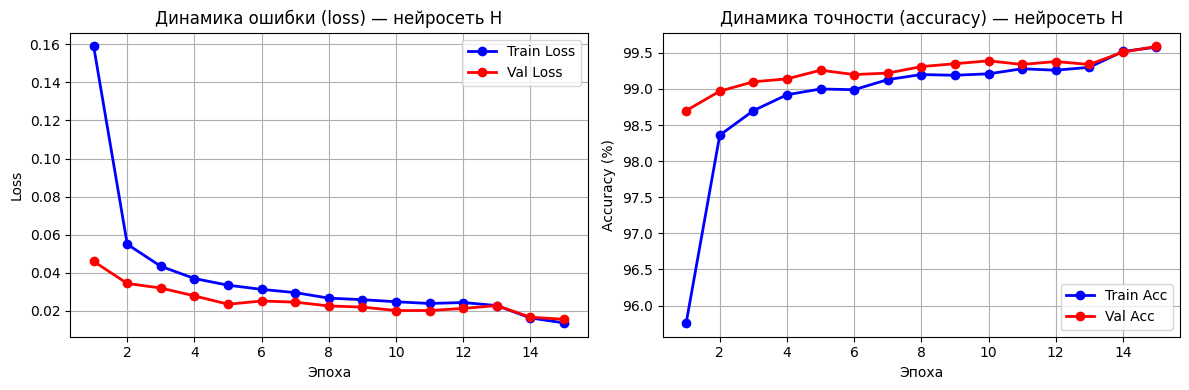

Лучшая точность на валидации: 99.59% (эпоха 15)
Финальная точность на тесте: 99.54% (по отчёту Н)


In [1]:
import sys
print(sys.executable)

/usr/bin/python3
